# 4.1 벨만 최적방정식과 정책평가 — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml2/chapter04_1_bellman_policy_evaluation.ipynb)

책 본문: [4.1 벨만 최적방정식과 정책평가](https://smhanlab.com/book-ml/kor/ml2/chapter04/1.html)

이 노트북은 4.1절의 네 가지를 **실행**해본다.

1. **정책평가의 두 길**: 같은 3-state 순환 MDP를 (a) 연립 일차방정식으로 **직접** 풀고, (b) **반복적** 정책평가로 풀어 **같은 답**이 나오는지 확인
2. **수렴 속도**: sweep 수가 오차에 미치는 영향 — "오류가 sweep마다 \(\times\gamma\)로 줄어든다"를 눈으로 확인
3. **두 정책 비교**: 5칸 GridWorld에서 "오른쪽" vs "왼쪽" 정책의 \(V\) 수렴 곡선을 그린다
4. **\(Q^\pi\) 표와 정책개선 예고**: \(V^\pi\)를 \(Q^\pi\)로 확장하고, 행별 \(\arg\max\)가 **다음 절(4.2)**에서 하는 "정책개선"의 본체임을 보여준다



In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Noto Sans CJK KR"
plt.rcParams["axes.unicode_minus"] = False


## 1. 반복적 정책평가 (4.1절의 코드)

벨만 기대방정식 \(V^\pi(s) = R(s,\pi(s)) + \gamma \sum_{s'} P(s'|s,\pi(s)) V^\pi(s')\)의 우변을
같은 값에 반복 대입하는 `policy_evaluation` — in-place(가우시) 방식이다.



In [2]:
def policy_evaluation(P, R, policy, gamma, theta=1e-6):
    n_states = len(P)
    V = [0.0] * n_states
    n_sweeps = 0
    while True:
        delta = 0
        for s in range(n_states):
            a = policy[s]
            v_new = R[s][a] + gamma * sum(prob * V[next_s] for prob, next_s in P[s][a])
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        n_sweeps += 1
        if delta < theta:
            break
    return V, n_sweeps


## 2. 3-state 순환 MDP: 두 "길"이 같은 답인가

- 상태 0: 보상 \(+1\), 항상 상태 1로 전이
- 상태 1: 보상 \(+2\), 0.7 확률로 상태 2, 0.3 확률로 상태 0
- 상태 2: 보상 \(0\), 항상 상태 0으로 전이

행동이 하나뿐이므로 정책은 자명하다(`[0,0,0]`). **순환**이 있어서
"터미널부터 거꾸로 대입"으로 안 풀리고, (a) 연립방정식 직접 풀이와
(b) 반복법 두 가지가 필요하다.



In [3]:
# P[s][a] = [(prob, next_state), ...],  R[s][a] = 즉시 보상
P3 = [
    [[(1.0, 1)]],            # state 0 --(a0, +1)--> state 1
    [[(0.7, 2), (0.3, 0)]],  # state 1 --(a0, +2)--> 2 (p=0.7) / 0 (p=0.3)
    [[(1.0, 0)]],            # state 2 --(a0, +0)--> state 0
]
R3 = [[1], [2], [0]]
policy3 = [0, 0, 0]
gamma = 0.9


### 2a. 반복적 정책평가


In [4]:
V3, sweeps3 = policy_evaluation(P3, R3, policy3, gamma)
print(f"sweep {sweeps3}회 후 수렴:")
for s, v in enumerate(V3):
    print(f"  V({s}) = {v:.4f}")


sweep 88회 후 수렴:
  V(0) = 11.3498
  V(1) = 11.4998
  V(2) = 10.2148


### 2b. 연립 일차방정식으로 직접 풀어보기

벨만방정식 3개를 `A @ v = b` 행렬 형태로 쓴 뒤 `np.linalg.solve`로
한 번에 푼다. `A`의 \((s, s')\) 원소는 \(-\gamma P(s'|s)\)이고
대각은 \(1 - \gamma P(s|s)\)(자기 전이가 있으면 1), `b`는 즉시 보상이다.



In [5]:
n = 3
A = np.zeros((n, n))
b = np.zeros(n)
for s in range(n):
    a = policy3[s]
    A[s, s] = 1.0
    for prob, ns in P3[s][a]:
        A[s, ns] -= gamma * prob
    b[s] = R3[s][a]
V_direct = np.linalg.solve(A, b)
print("직접 풀이 (np.linalg.solve):", [f"{v:.4f}" for v in V_direct])
print("반복   (policy_evaluation): ", [f"{v:.4f}" for v in V3])
print("최대 차이:", f"{np.max(np.abs(np.array(V3) - V_direct)):.2e}")
assert np.allclose(V3, V_direct, atol=1e-4), "두 경로가 다른 값!"
print("\n두 '길'이 같은 답에 도달했다 — 벨만방정식의 고정점은 유일하다. (4.3절에서 증명)")


직접 풀이 (np.linalg.solve): ['11.3498', '11.4998', '10.2148']
반복   (policy_evaluation):  ['11.3498', '11.4998', '10.2148']
최대 차이: 4.87e-06

두 '길'이 같은 답에 도달했다 — 벨만방정식의 고정점은 유일하다. (4.3절에서 증명)


### 2c. 손으로 푼 값 검산

본문 "방법 1"의 대입 정리:
\(V(0) = 1 + 0.9 V(1)\), \(V(1) = 2 + 0.63 V(2) + 0.27 V(0)\), \(V(2) = 0.9 V(0)\).
상태 1식을 0식에 대입: \(V(0) = 2.8 + 0.567 V(2) + 0.243 V(0)\).
그다음 \(V(2) = 0.9 V(0)\) 대입: \(V(0) = 2.8 + (0.567\times0.9) V(0) + 0.243 V(0)
= 2.8 + 0.5103 V(0) + 0.243 V(0)\).
\(\Rightarrow 0.2467\,V(0) = 2.8\), \(V(0) = 2.8/0.2467 \approx 11.3498\).



In [6]:
V0_hand = 2.8 / (1 - 0.567*0.9 - 0.243)   # = 2.8/(1 - 0.5103 - 0.243) = 2.8/0.2467
V2_hand = 0.9 * V0_hand
V1_hand = 2 + 0.63 * V2_hand + 0.27 * V0_hand
print(f"손계산: V0={V0_hand:.4f}, V1={V1_hand:.4f}, V2={V2_hand:.4f}")
print(f"코드:   V0={V3[0]:.4f}, V1={V3[1]:.4f}, V2={V3[2]:.4f}")
assert abs(V3[0] - V0_hand) < 1e-4 and abs(V3[1] - V1_hand) < 1e-4 and abs(V3[2] - V2_hand) < 1e-4
print("모두 일치 ✓")


손계산: V0=11.3498, V1=11.4998, V2=10.2148
코드:   V0=11.3498, V1=11.4998, V2=10.2148
모두 일치 ✓


## 3. 수렴 속도: "오류가 sweep마다 \(\times\gamma\)로 줄어든다"

4.3절의 축소 사상(contraction) 성질 \(\|V_{k+1}-V^\pi\|_\infty \le \gamma
\|V_k-V^\pi\|_\infty\)을 **로그 스케일** 그래프로 확인한다. 직선의 기울기가
\(\log_{10}\gamma\)인지도 확인해본다.



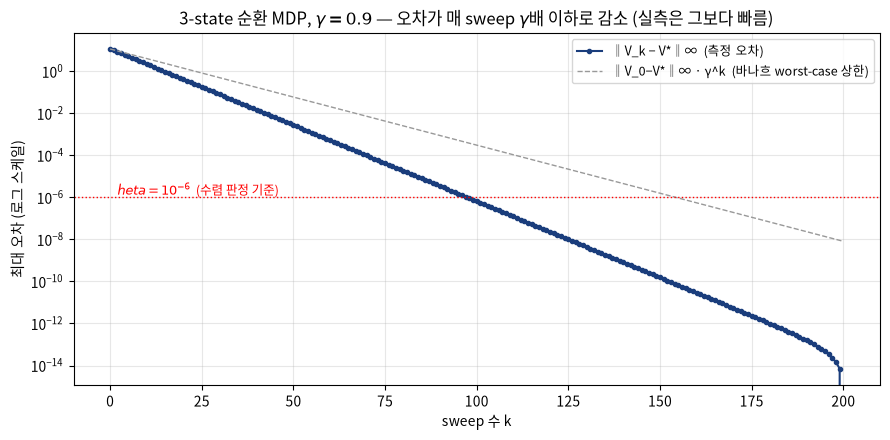

초기 오차 ||V_0 - V*||_inf = 11.4998
오차가 절반이 되는 sweep 수 (측정): 5  (worst-case 상한: log(0.5)/log(0.9) = 6.58)
오차가 1e-6까지 (측정): 98 sweep  (worst-case 상한: log(1e-6)/log(0.9) = 131 sweep)
  -> 바나흐 bound는 '최악의 경우'이고, 실제 수렴은 초기 오차의 고주파 성분이 빨리 감쇠해 그보다 빠를 수 있다


In [7]:
def pe_with_history(P, R, policy, gamma, n_sweeps, theta=None):
    n = len(P)
    V = [0.0] * n
    hist = [list(V)]
    for k in range(n_sweeps):
        delta = 0
        for s in range(n):
            a = policy[s]
            v = R[s][a] + gamma * sum(p * V[ns] for p, ns in P[s][a])
            delta = max(delta, abs(v - V[s]))
            V[s] = v
        hist.append(list(V))
        if theta is not None and delta < theta:
            break
    return V, hist

V3_star, hist3 = pe_with_history(P3, R3, policy3, gamma, n_sweeps=200)
errors = [max(abs(a - b) for a, b in zip(v, V3_star)) for v in hist3]
k_idx = np.arange(len(errors))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(k_idx, errors, "o-", ms=3, lw=1.5, color="#1a3d7c",
            label="‖V_k − V*‖∞  (측정 오차)")
# reference: gamma^k * ||V_0 - V*||  (worst-case upper bound)
upper = errors[0] * gamma ** k_idx
ax.semilogy(k_idx, upper, "--", color="#999", lw=1,
            label="‖V_0−V*‖∞ · γ^k  (바나흐 worst-case 상한)")
ax.axhline(1e-6, color="red", ls=":", lw=1)
ax.text(2, 1.3e-6, "$\theta = 10^{-6}$  (수렴 판정 기준)", fontsize=9, color="red")
ax.set_xlabel("sweep 수 k"); ax.set_ylabel("최대 오차 (로그 스케일)")
ax.set_title("3-state 순환 MDP, $\gamma=0.9$ — 오차가 매 sweep $\gamma$배 이하로 감소 (실측은 그보다 빠름)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
err = np.array(errors)
print(f"초기 오차 ||V_0 - V*||_inf = {err[0]:.4f}")
print(f"오차가 절반이 되는 sweep 수 (측정): {np.argmax(err < err[0]/2)}  (worst-case 상한: log(0.5)/log(0.9) = {np.log(0.5)/np.log(0.9):.2f})")
print(f"오차가 1e-6까지 (측정): {np.argmax(err < 1e-6)} sweep  (worst-case 상한: log(1e-6)/log(0.9) = {np.log(1e-6)/np.log(0.9):.0f} sweep)")
print("  -> 바나흐 bound는 '최악의 경우'이고, 실제 수렴은 초기 오차의 고주파 성분이 빨리 감쇠해 그보다 빠를 수 있다")


## 4. 5칸 GridWorld: 두 정책 나란히 평가하기

4.2절의 GridWorld(칸 0~4, 칸 4가 목표, 걸음마다 \(-1\), \(\gamma=0.9\)).
**"오른쪽" 정책**(모든 칸에서 오른쪽)과 **"왼쪽" 정책**(모든 칸에서
왼쪽)의 \(V(0)\) 수렴 곡선을 sweep 단위로 그린다.



(SVG 저장됨: /home/smhan/book-ml/kor/src/images/ch04_1_policy_evaluation_convergence.svg)


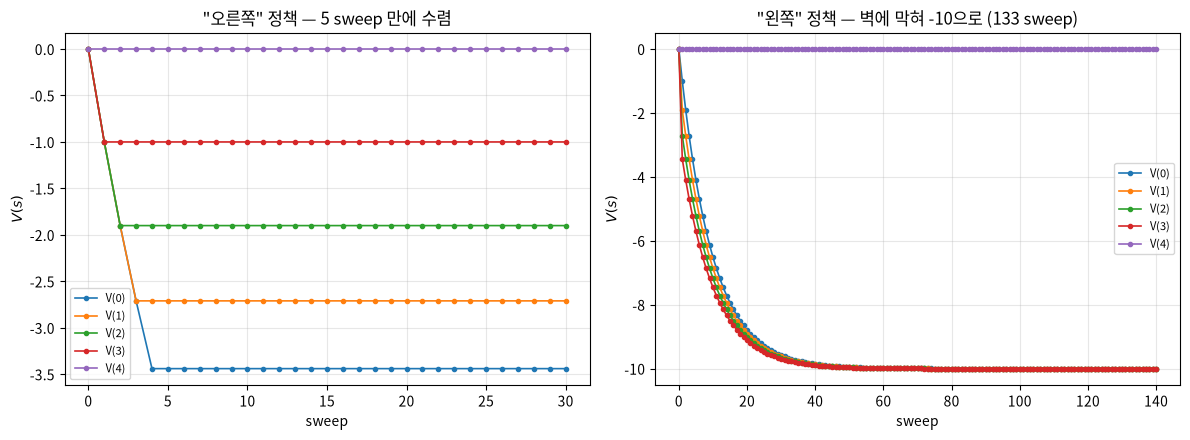

V_right: ['-3.4390', '-2.7100', '-1.9000', '-1.0000', '0.0000']   (수렴 sweep: 5)
V_left : ['-10.0000', '-10.0000', '-10.0000', '-10.0000', '0.0000']   (수렴 sweep: 133)

왼쪽 정책의 수렴값 -10 = sum_{k>=0} (-1)(0.9)^k = -1/(1-0.9) = -10.0000


In [8]:
n_states, n_actions = 5, 2
P, R = {}, {}
for s in range(n_states):
    P[s], R[s] = {}, {}
    for a in range(n_actions):
        if s == 4:
            P[s][a], R[s][a] = [(1.0, 4)], 0.0
        else:
            ns = max(0, s - 1) if a == 0 else min(4, s + 1)
            P[s][a], R[s][a] = [(1.0, ns)], -1.0

policy_right = [1, 1, 1, 1, 0]
policy_left  = [0, 0, 0, 0, 1]

Vr, histR = pe_with_history(P, R, policy_right, gamma, n_sweeps=30)
Vl, histL = pe_with_history(P, R, policy_left, gamma, n_sweeps=140)  # 왼쪽 정책은 133 sweep까지 수렴

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for s in range(5):
    ax.plot([h[s] for h in histR], marker="o", ms=3, lw=1.2, label=f"V({s})")
ax.set_title("\"오른쪽\" 정책 — 5 sweep 만에 수렴")
ax.set_xlabel("sweep"); ax.set_ylabel(r"$V(s)$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for s in range(5):
    ax.plot([h[s] for h in histL], marker="o", ms=3, lw=1.2, label=f"V({s})")
ax.set_title("\"왼쪽\" 정책 — 벽에 막혀 -10으로 (133 sweep)")
ax.set_xlabel("sweep"); ax.set_ylabel(r"$V(s)$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
# 로컬 저장소가 있으면 책 본문이 쓸 SVG로 저장 (Colab에서는 자동 스킵)
import os
_img = "/home/smhan/book-ml/kor/src/images/ch04_1_policy_evaluation_convergence.svg"
if os.path.isdir(os.path.dirname(_img)):
    plt.savefig(_img, bbox_inches="tight")
    print("(SVG 저장됨:", _img + ")")
plt.show()
print("V_right:", [f"{v:.4f}" for v in Vr], f"  (수렴 sweep: {policy_evaluation(P, R, policy_right, gamma)[1]})")
print("V_left :", [f"{v:.4f}" for v in Vl], f"  (수렴 sweep: {policy_evaluation(P, R, policy_left, gamma)[1]})")
print("\n왼쪽 정책의 수렴값 -10 = sum_{k>=0} (-1)(0.9)^k = -1/(1-0.9) =", f"{-1/(1-gamma):.4f}")


## 5. \(Q^\pi\) 표와 정책개선 예고 (→ 4.2절)

\(V^\text{right}\)를 \(Q(s,a) = R(s,a) + \gamma V(s')\)로 확장해 표를
채운다. **행별 \(\arg\max\)가 "오른쪽" 정책 자신과 일치하는** 것을
보여준다 — 4.2절의 정책개선 단계에서 "바꿀 것이 없다"고 판단하는
상태, 즉 **policy-stationary** 상태다. 이것이 곧 이 정책이
**이 MDP에서** 최적임을 암시하는 증거(4.2절에서 정식 정리로).



In [9]:
def q_table(P, R, V, n_actions, gamma):
    n = len(P)
    return [[R[s][a] + gamma * sum(p * V[ns] for p, ns in P[s][a]) for a in range(n_actions)]
            for s in range(n)]

Qr = q_table(P, R, Vr, n_actions, gamma)
print(f"{'s':>3}  {'Q(s,left)':>10}  {'Q(s,right)':>11}   argmax")
for s in range(n_states):
    best = max(range(n_actions), key=lambda a: Qr[s][a])
    mark = " (동점)" if Qr[s][0] == Qr[s][1] else ""
    print(f"{s:>3}  {Qr[s][0]:>+10.4f}  {Qr[s][1]:>+11.4f}   {'left' if best==0 else 'right'}{mark}")

# V(s) == Q(s, pi(s)) 다리가 실제로 성립하는지
print("\n'다리' V(s) == Q(s, pi(s)) 검증:")
for s in range(n_states):
    assert abs(Vr[s] - Qr[s][policy_right[s]]) < 1e-9
print("  모든 상태에서 V(s) = Q(s, pi(s)) ✓")


  s   Q(s,left)   Q(s,right)   argmax
  0     -4.0951      -3.4390   right
  1     -4.0951      -2.7100   right
  2     -3.4390      -1.9000   right
  3     -2.7100      -1.0000   right
  4     +0.0000      +0.0000   left (동점)

'다리' V(s) == Q(s, pi(s)) 검증:
  모든 상태에서 V(s) = Q(s, pi(s)) ✓


## 6. 확인: 벨만 최적방정식과 이 GridWorld

4.1절에서 도입한 벨만 **최적**방정식 \(V^*(s) = \max_a [R(s,a) + \gamma
\sum_{s'} P(s'|s,a) V^*(s')]\)의 우변을, **\(V^\text{right}\) 값에** 대입
해보면 — "오른쪽" 정책이 이미 각 상태에서 \(\max\)를 달성하고 있으므로
**등호가 성립**한다. 이 "우변을 대입해 본 값 = 현재 V"라는 조건이
4.3절에서 다룰 \(V^*\)의 **고정점** 판별법이다.



In [10]:
print("벨만 최적방정식 고정점 판별 (V_right에 우변 대입):")
residuals = []
for s in range(n_states):
    rhs = max(R[s][a] + gamma * sum(p * Vr[ns] for p, ns in P[s][a]) for a in range(n_actions))
    res = abs(rhs - Vr[s])
    residuals.append(res)
    print(f"  state {s}: V(s)={Vr[s]:+.4f}   max_a[...]={rhs:+.4f}   |차이|={res:.2e}")
print(f"\n최대 잔차 = {max(residuals):.2e}  (< 1e-9 이므로 V_right는 벨만 최적방정식의 고정점)")
print("=> '오른쪽' 정책의 V가 V*와 같다는 직접 증거 (4.2절 정책 반복이 첫 sweep에서 멈추는 이유)")


벨만 최적방정식 고정점 판별 (V_right에 우변 대입):
  state 0: V(s)=-3.4390   max_a[...]=-3.4390   |차이|=0.00e+00
  state 1: V(s)=-2.7100   max_a[...]=-2.7100   |차이|=0.00e+00
  state 2: V(s)=-1.9000   max_a[...]=-1.9000   |차이|=0.00e+00
  state 3: V(s)=-1.0000   max_a[...]=-1.0000   |차이|=0.00e+00
  state 4: V(s)=+0.0000   max_a[...]=+0.0000   |차이|=0.00e+00

최대 잔차 = 0.00e+00  (< 1e-9 이므로 V_right는 벨만 최적방정식의 고정점)
=> '오른쪽' 정책의 V가 V*와 같다는 직접 증거 (4.2절 정책 반복이 첫 sweep에서 멈추는 이유)
